# 🎵 تحلیل احساسات نقدهای اسپاتیفای با شبکه Bi-LSTM

## 📚 توضیح کلی پروژه

این پروژه به تحلیل احساسات (Sentiment Analysis) نقدهای کاربران برای اپلیکیشن Spotify (موسیقی) می‌پردازد.

### 🎯 هدف پروژه
- **ورودی**: نقدهای متنی کاربران از فروشگاه پلی 
- **خروجی**: پیش‌بینی احساس نقد (منفی / خنثی / مثبت)
- **روش**: استفاده از شبکه عصبی عمیق **Bi-LSTM** (دوطرفه)

### 🏗️ معماری مدل

```
نقد متنی (Input)
     ↓
[Embedding Layer] → تبدیل کلمات به بردارهای متراکم
     ↓
[Bi-LSTM 64] → درک دوطرفه (چپ ← → راست)
     ↓
[Dropout 0.3] → جلوگیری از بیش‌فیt
     ↓
[Bi-LSTM 32] → بیشتر الگو‌ها را یاد بگیر
     ↓
[Dense 64 + ReLU] → ترکیب ویژگی‌ها
     ↓
[Dense 3 + Softmax] → احتمالات: [منفی, خنثی, مثبت]
```

### 📊 مراحل پروژه

| مرحله | توضیح | خروجی |
|------|-------|------|
| **1. لود داده** | بارگذاری CSV | DataFrame |
| **2. پاکیزه‌سازی** | حذف نقدهای خالی | داده‌های تمیز |
| **3. برچسب‌گذاری** | تبدیل Rating → احساس | 3 کلاس |
| **4. Tokenization** | کلمات → اعداد | دنباله‌های عددی |
| **5. آموزش** | تعلیم مدل | وزن‌های بهینه |
| **6. ارزیابی** | بررسی دقت | نتایج (Accuracy, AUC) |
| **7. پیش‌بینی** | تست نقدهای جدید | نتایج احساس |

### 🔑 مفاهیم کلیدی

- **LSTM**: شبکه حافظه درازمدت (می‌تواند اطلاعات مهم را یاد نگاه‌دارد)
- **Bi-Directional**: خواندن از هر دو جهت (سمت راست و چپ)
- **Embedding**: نمایش کلمات در فضای چندبعدی
- **Dropout**: حذف تصادفی نورون‌ها برای جلوگیری از بیش‌فیt

---



In [ ]:
# ==========================================
# استیراد کتابخانه‌ها - تمام کتابخانه‌های لازم را وارد می‌کنیم
# ==========================================
import pandas as pd                                      # دستکاری داده‌های جدولی (CSV، DataFrame)
import numpy as np                                       # عملیات ریاضی سریع بر روی آرایه‌ها
import matplotlib.pyplot as plt                          # رسم نمودارها و تجسم داده‌ها
import seaborn as sns                                    # تجسم بیشتر برای نمودارهای آماری (Heatmap)
import re                                                # عبارات منظم برای پاکیزه‌سازی متن
import tensorflow as tf                                  # فریم‌ورک یادگیری عمیق
from tensorflow.keras.preprocessing.text import Tokenizer  # تبدیل متن به اعداد (توکن‌سازی)
from tensorflow.keras.preprocessing.sequence import pad_sequences  # یکسان‌سازی طول دنباله‌ها
from tensorflow.keras.models import Sequential           # ساخت مدل خطی (لایه‌های متوالی)
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, Dropout  # اجزای شبکه عصبی
from sklearn.model_selection import train_test_split    # تقسیم داده‌ها به آموزش و تست
from sklearn.preprocessing import LabelEncoder          # تبدیل برچسب‌های متنی به اعداد
from sklearn.metrics import classification_report, confusion_matrix  # ارزیابی مدل

# ==========================================

In [ ]:

# 1. تنظیمات و بارگذاری داده‌ها
# ==========================================

# مسیر فایل CSV
FILE_PATH = 'ulasan_com.spotify.music.csv'

# ===== پارامترهای مدل - تنظیمات برای Tokenizer و LSTM =====
VOCAB_SIZE = 10000          # حداکثر تعداد کلمات منحصربه‌فرد (10000 کلمه پرتکرار)
                            # کلمات نادر به <OOV> تبدیل می‌شوند

EMBEDDING_DIM = 100         # ابعاد بردار نمایش کلمات
                            # بیشتر = ظرفیت بیشتر، اما نیاز به داده بیشتر
                            # معمول: 50-300، برای Spotify 100 کافی است

MAX_LENGTH = 120            # حداکثر طول دنباله (تعداد کلمات هر نقد)
                            # نقدهای بلندتر قطع‌می‌شوند، کوتاه‌تر بالشتک‌می‌شوند

TRUNC_TYPE = 'post'         # نوع قطع: 'post' = از انتها، 'pre' = از ابتدا
                            # 'post' استفاده می‌کنیم چون اطلاعات مهم در ابتدا است

PADDING_TYPE = 'post'       # نوع بالشتک: 'post' = اضافه 0 در انتها
                            # 'post' طبیعی‌تر برای پردازش متن است

OOV_TOK = "<OOV>"           # توکن برای کلمات نادر (خارج واژگان)
                            # مثال: اگر "zzzzzzz" در 10000 کلمه نیست → <OOV>

# بارگذاری فایل CSV
print("🔄 بارگذاری مجموعه داده‌ها...")
df = pd.read_csv(FILE_PATH)

# حذف سطرهای خالی از ستون نقدها
df = df.dropna(subset=['Ulasan'])
print(f"✓ کل داده‌های پاک‌شده: {len(df)} نقد")

# ==========================================
# 2. پیش‌پردازش برچسب‌ها (احساسات)
# ==========================================
# تبدیل امتیاز به احساس:
# امتیاز 1-2 → منفی (کاربر ناراضی)
# امتیاز 3   → خنثی (کاربر مردد)
# امتیاز 4-5 → مثبت (کاربر راضی)

def map_sentiment(rating):
    """
    تابع تبدیل امتیاز عددی به برچسب احساس
    Parameters:
        rating (int): امتیاز کاربر (1-5)
    Returns:
        str: برچسب احساس ('منفی'، 'خنثی'، یا 'مثبت')
    """
    if rating <= 2:
        return 'Negatif'
    elif rating == 3:
        return 'Netral'
    else:
        return 'Positif'


# اعمال تابع نقشه برداری روی تمام امتیازات
df['sentiment'] = df['Rating'].apply(map_sentiment)

print("\n📊 توزیع برچسب‌های احساس:")
print(df['sentiment'].value_counts())

# تبدیل برچسب‌های احساس (متن) به اعداد
# منفی = 0، خنثی = 1، مثبت = 2
le = LabelEncoder()                          # مقداردهی کننده برچسب
labels = le.fit_transform(df['sentiment'])   # تبدیل: 'منفی'→0، 'خنثی'→1، 'مثبت'→2
num_classes = len(np.unique(labels))         # تعداد کلاس‌های منحصربه‌فرد (باید 3 باشد)
print(f"✓ تعداد کلاس‌ها: {num_classes}")

# ==========================================
# 3. پیش‌پردازش متن (پاکیزه‌سازی)
# ==========================================

def clean_text(text):
    """
    تابع پاکیزه‌سازی متن نقد از کاراکتر‌های غیرضروری
    Parameters:
        text (str): متن خام نقد
    Returns:
        str: متن پاک‌شده (کوچک‌ حروف، بدون کاراکتر خاص)
    """
    text = str(text).lower()                      # تبدیل به حروف کوچک
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)   # حذف تمام کاراکتر جز حروف و اعداد
                                                  # الگو: [^...] = نه (...)
    return text

print("\n🧹 پاکیزه‌سازی متن‌ها...")
df['clean_text'] = df['Ulasan'].apply(clean_text)  # ستون جدید: متن‌های پاک‌شده
reviews = df['clean_text'].values                  # آرایه تمام نقدهای پاک‌شده

# ==========================================
# 4. توکن‌سازی و بالشتک‌کاری
# ==========================================

print("🔤 توکن‌سازی متن‌ها...")

# توکن‌ساز: تبدیل کلمات → اعداد بر اساس فرکانس
tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,           # واژگان: 10000 کلمه پرتکرار
    oov_token=OOV_TOK               # کلمات نادر: <OOV>
)
tokenizer.fit_on_texts(reviews)     # یادگیری واژگان از تمام نقدها

# تبدیل نقدها به دنباله‌های عددی
# مثال: "اپلیکیشن بهتره" → [125, 407] (اگر 125=اپلیکیشن، 407=بهتره)
sequences = tokenizer.texts_to_sequences(reviews)

# یکسان‌سازی طول دنباله‌ها (همه 120 عنصر)
# نقدهای کوتاه: اضافه 0 در انتها
# نقدهای بلند: قطع از انتها
padded = pad_sequences(
    sequences,                      # دنباله‌های توکن‌شده
    maxlen=MAX_LENGTH,              # طول هدف: 120 توکن
    padding=PADDING_TYPE,           # 'post': 0 در انتها
    truncating=TRUNC_TYPE           # 'post': قطع از انتها
)

print(f"✓ شکل داده بعد از بالشتک: {padded.shape}")  # خروجی: (N, 120)

# تقسیم داده‌ها: 80% آموزش، 20% تست
X_train, X_test, y_train, y_test = train_test_split(
    padded,                         # ویژگی‌های ورودی (نقدهای عددی)
    labels,                         # برچسب‌های هدف (احساسات: 0/1/2)
    test_size=0.2,                  # 20% برای تست
    random_state=42 ,                # بذر برای تکرارپذیری
    stratify=labels
)

print(f"📈 داده‌های آموزشی (80%): {X_train.shape}")
print(f"📊 داده‌های تستی (20%):   {X_test.shape}")

# ==========================================
# 5. ساخت مدل Bi-LSTM
# ==========================================

model = Sequential([
    # لایه 1: Embedding
    # تبدیل توکن‌های عددی → بردارهای متراکم 100-بعدی
    Embedding(
        input_dim=VOCAB_SIZE,           # اندازه واژگان (10000)
        output_dim=EMBEDDING_DIM,       # ابعاد خروجی (100)
        input_length=MAX_LENGTH         # طول ورودی (120)
    ),
    
    # لایه 2: Bi-LSTM دوطرفه (64 واحد)
    # خواندن دنباله در 2 جهت: چپ←→راست
    # درک متن از هر دو طرف کلمات
    Bidirectional(
        LSTM(
            units=64,                   # 64 forward + 64 backward = 128 کل
            return_sequences=True       # بازگرداندن تمام دنباله
        )
    ),
    
    # لایه 3: Dropout (30%)
    # غیرفعال کردن 30% نورون‌ها برای جلوگیری از بیش‌برازش
    Dropout(rate=0.3),
    
    # لایه 4: Bi-LSTM دوطرفه دوم (32 واحد)
    # 32 forward + 32 backward = 64 کل
    Bidirectional(
        LSTM(
            units=32,                   # واحدهای LSTM کوچک‌تر
            return_sequences=False      # تنها حالت نهایی
        )
    ),
    
    # لایه 5: Dropout (30%)
    Dropout(rate=0.3),
    
    # لایه 6: Dense (64 واحد، ReLU)
    # ترکیب ویژگی‌های LSTM
    Dense(
        units=64,                       # 64 نورون
        activation='relu'               # فعال‌سازی ReLU: f(x) = max(0, x)
    ),
    
    # لایه 7: خروجی Dense (3 واحد، Softmax)
    # خروجی برای 3 کلاس: منفی(0)، خنثی(1)، مثبت(2)
    # احتمالات جمع = 1
    # مثال: [0.1, 0.2, 0.7] = 10% منفی، 20% خنثی، 70% مثبت
    Dense(
        units=num_classes,              # خروجی = تعداد کلاس (3)
        activation='softmax'            # تبدیل به احتمالات
    )
])

# کامپایل مدل: تعریف تابع خسارت، بهینه‌ساز، معیارها
model.compile(
    loss='sparse_categorical_crossentropy',  # خسارت برای چند‌کلاسه
                                             # 'sparse' = برچسب‌های عددی
    optimizer='adam',                        # بهینه‌ساز: Adam
                                             # تعدیل خودکار نرخ یادگیری
    metrics=['accuracy']                     # معیار: دقت (درصد صحیح)
)

# نمایش معماری مدل
print("\n🏗️ معماری مدل Bi-LSTM:")
model.summary()


In [7]:

# ==========================================
# 6. آموزش مدل
# ==========================================

# EarlyStopping: توقف اگر بهبودی نباشد
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',                 # نظارت بر خسارت اعتبارسنجی
    patience=3,                         # توقف اگر 3 Epoch بهبود نباشد
    restore_best_weights=True           # بازگرداندن بهترین وزن‌ها
)

print("\n" + "="*50)
print("🚀 آموزش مدل شروع می‌شود")
print("="*50)

# آموزش مدل
history = model.fit(
    X_train,                            # داده‌های آموزش
    y_train,                            # برچسب‌های آموزش
    epochs=10,                          # 10 دور (1 دور = تمام داده 1 بار)
    validation_data=(X_test, y_test),   # داده‌های اعتبارسنجی
    batch_size=128,                     # 128 نمونه در هر به‌روزرسانی
    callbacks=[early_stop],             # استفاده از Early Stopping
    verbose=1                           # نمایش پیشرفت هر Epoch
)


625/625 ━━━━━━━━━━━━━━━━━━━━ 178s 271ms/step - accuracy: 0.8663 - loss: 0.3959 - val_accuracy: 0.8877 - val_loss: 0.3425
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 184s 295ms/step - accuracy: 0.8947 - loss: 0.3230 - val_accuracy: 0.8906 - val_loss: 0.3320
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 172s 275ms/step - accuracy: 0.9026 - loss: 0.2954 - val_accuracy: 0.8886 - val_loss: 0.3384
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 167s 266ms/step - accuracy: 0.9091 - loss: 0.2754 - val_accuracy: 0.8894 - val_loss: 0.3527
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 163s 261ms/step - accuracy: 0.9162 - loss: 0.2575 - val_accuracy: 0.8831 - val_loss: 0.3542


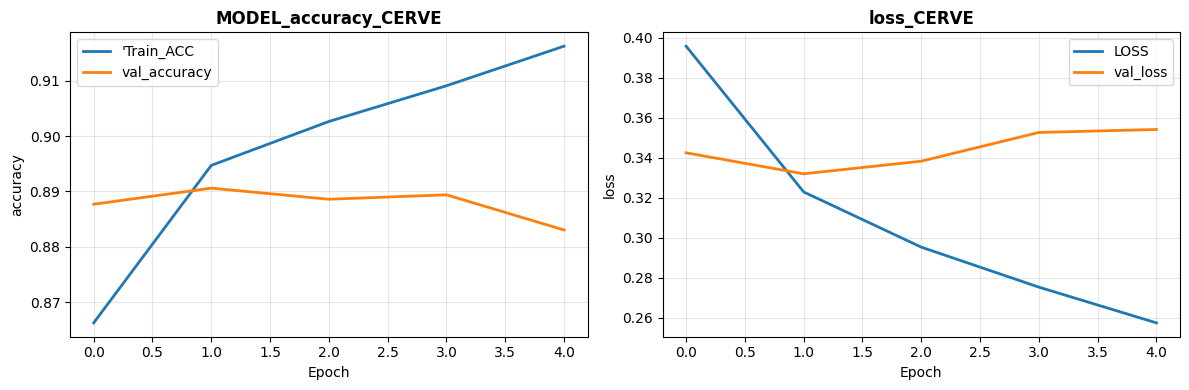


📋 گزارش طبقه‌بندی روی داده‌های تستی
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 27ms/step


e:\python3.12\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\python3.12\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\python3.12\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

     Negatif     0.7353    0.8542    0.7903      3938
      Netral     0.0000    0.0000    0.0000       928
     Positif     0.9367    0.9547    0.9456     15134

    accuracy                         0.8906     20000
   macro avg     0.5573    0.6030    0.5786     20000
weighted avg     0.8536    0.8906    0.8711     20000


🎯 آزمون دستی - پیش‌بینی احساس
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 871ms/step

📝 نقد: Aplikasi ini sering error, tidak bisa putar lagu
✅ احساس پیش‌بینی‌شده: Negatif
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step

📝 نقد: Suka banget, fiturnya lengkap dan suaranya jernih
✅ احساس پیش‌بینی‌شده: Positif
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step

📝 نقد: Biasalah, kadang bagus kadang lemot
✅ احساس پیش‌بینی‌شده: Positif


In [8]:

# ==========================================
# 7. ارزیابی و نمودار
# ==========================================

# نمودار دقت و خسارت
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# نمودار 1: دقت
axes[0].plot(history.history['accuracy'], label="'Train_ACC", linewidth=2)
axes[0].plot(history.history['val_accuracy'], label="val_accuracy", linewidth=2)
axes[0].set_title("MODEL_accuracy_CERVE", fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# نمودار 2: خسارت
axes[1].plot(history.history['loss'], label='LOSS', linewidth=2)
axes[1].plot(history.history['val_loss'], label="val_loss", linewidth=2)
axes[1].set_title('loss_CERVE', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# گزارش طبقه‌بندی تفصیلی
print("\n" + "="*50)
print("📋 گزارش طبقه‌بندی روی داده‌های تستی")
print("="*50)

y_pred = np.argmax(model.predict(X_test), axis=-1)  # پیش‌بینی: بیشترین احتمال
target_names = le.classes_  # ['منفی', 'خنثی', 'مثبت']

print(classification_report(
    y_test,                             # برچسب‌های واقعی
    y_pred,                             # پیش‌بینی‌های مدل
    target_names=target_names,          # نام‌های کلاس
    digits=4                            # دقت 4 رقم اعشار
))

# ==========================================
# 8. آزمون دستی (پیش‌بینی)
# ==========================================

def prediksi_kalimat(kalimat):
    """
    تابع پیش‌بینی احساس یک نقد جدید
    Parameters:
        kalimat (str): نقدی که می‌خواهیم احساس آن را بیابیم
    Returns:
        str: احساس پیش‌بینی‌شده ('منفی'، 'خنثی'، یا 'مثبت')
    """
    # توکن‌سازی و بالشتک کاری نقد جدید
    seq = tokenizer.texts_to_sequences([clean_text(kalimat)])  # متن → اعداد
    pad = pad_sequences(seq, maxlen=MAX_LENGTH, padding=PADDING_TYPE, truncating=TRUNC_TYPE)
    
    # پیش‌بینی: 3 احتمال خروجی
    pred = model.predict(pad)  # خروجی: [[احتمال_منفی, احتمال_خنثی, احتمال_مثبت]]
    
    # انتخاب کلاس با بیشترین احتمال
    label_idx = np.argmax(pred)  # مثال: argmax([0.1, 0.2, 0.7]) = 2 (مثبت)
    
    # تبدیل عدد به برچسب متنی
    return le.inverse_transform([label_idx])[0]

print("\n" + "="*50)
print("🎯 آزمون دستی - پیش‌بینی احساس")
print("="*50)

# نقدهای نمونه برای آزمون
contoh_review = [
    "Aplikasi ini sering error, tidak bisa putar lagu",  # Seharusnya: Negatif
    "Suka banget, fiturnya lengkap dan suaranya jernih",  # Seharusnya: Positif
    "Biasalah, kadang bagus kadang lemot"                 # Seharusnya: Netral
]

for review in contoh_review:
    prediksi = prediksi_kalimat(review)
    print(f"\n📝 نقد: {review}")
    print(f"✅ احساس پیش‌بینی‌شده: {prediksi}")


In [ ]:
! pip install ml_dtypes

In [9]:
from sklearn.utils import class_weight

# ==========================================
# محاسبه وزن کلاس‌ها برای موازنه داده‌های نامتوازن
# ==========================================

# 1. محاسبه وزن برای هر کلاس
# کلاس‌هایی با داده‌های کمتر وزن بیشتری دریافت می‌کنند
# این برای جلوگیری از نادیده گرفتن کلاس‌های کم‌فراوان است
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',                    # روش: متوازن کردن خودکار
                                                # هر کلاس بر اساس تعداد نمونه‌هایش وزن می‌گیرد
    classes=np.unique(y_train),                 # کلاس‌های موجود (0, 1, 2)
    y=y_train                                   # برچسب‌های داده‌های آموزشی
)

# تبدیل وزن‌ها به فرمت دیکشنری برای Keras
# مثال خروجی: {0: 1.5, 1: 5.0, 2: 0.5}
# معنی: کلاس 0 وزن 1.5، کلاس 1 وزن 5.0 (کلاس کم‌تر)، کلاس 2 وزن 0.5
weights_dict = dict(enumerate(class_weights))
print("وزن‌های کلاس:", weights_dict)

# 2. استفاده از وزن‌ها در فرآیند آموزش مدل
# مدل به کلاس‌های نادر توجه بیشتری می‌دهد
history = model.fit(
    X_train,                                    # داده‌های ورودی (نقدها)
    y_train,                                    # برچسب‌های هدف (احساسات)
    epochs=10,                                  # تعداد Epoch‌ها (10 بار همه داده)
    validation_data=(X_test, y_test),           # داده‌های اعتبارسنجی
    batch_size=128,                             # اندازه هر دسته (128 نمونه در هر update)
    callbacks=[early_stop],                     # استفاده از EarlyStopping
    class_weight=weights_dict,                  # <<< ایجاد وزن‌های کلاس برای متوازنه‌سازی
    verbose=1                                   # 1 = نمایش پیشرفت هر Epoch
)

print("\n" + "="*50)
print("آموزش مدل با وزن‌های متوازن تکمیل شد")
print("="*50)


وزن‌های کلاس: {0: 1.6930142001566038, 1: 7.181973247149655, 2: 0.4405092286683406}
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 172s 268ms/step - accuracy: 0.8328 - loss: 0.6579 - val_accuracy: 0.8306 - val_loss: 0.4936
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 151s 242ms/step - accuracy: 0.8493 - loss: 0.5857 - val_accuracy: 0.8266 - val_loss: 0.5122
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 165s 264ms/step - accuracy: 0.8633 - loss: 0.5323 - val_accuracy: 0.8264 - val_loss: 0.5341

آموزش مدل با وزن‌های متوازن تکمیل شد


#P	75670	0.440509229	33333.33333
N	19689	1.6930142	33333.75659
NH	4641	7.181973247	33331.53784


In [ ]:
print(classification_report(y_test, y_pred_weighted, target_names=['Negatif', 'Netral', 'Positif']))


625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step

گزارش طبقه‌بندی تفصیلی (با وزن‌های کلاس)
              precision    recall  f1-score   support

     Negatif       0.77      0.72      0.74      3938
      Netral       0.17      0.47      0.25       928
     Positif       0.96      0.88      0.92     15134

    accuracy                           0.83     20000
   macro avg       0.64      0.69      0.64     20000
weighted avg       0.89      0.83      0.86     20000


ساخت ماتریس درهم‌ریختگی...


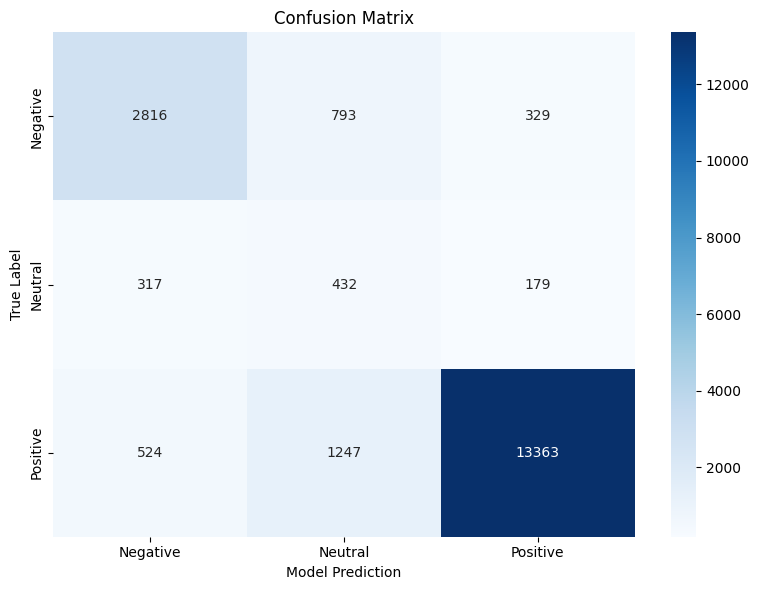


تفسیر ماتریس:
- سلول‌های قطری (diagonal) = پیش‌بینی‌های صحیح (بهتر)
- سلول‌های خارج قطری = پیش‌بینی‌های غلط (بدتر)


In [10]:
# ==========================================
# ارزیابی مدل: گزارش طبقه‌بندی و ماتریس درهم‌ریختگی
# ==========================================

# 1. تولید پیش‌بینی برای داده‌های آزمایش
# argmax: کدام کلاس بیشترین احتمال را دارد
# مثال: [0.1, 0.8, 0.1] → argmax = 1 (کلاس 1 / احساس مثبت)
y_pred_weighted = np.argmax(model.predict(X_test), axis=-1)

# 2. چاپ گزارش تفصیلی طبقه‌بندی
# شامل: Precision (دقت)، Recall (یادآوری)، F1-Score
print("\n" + "="*60)
print("گزارش طبقه‌بندی تفصیلی (با وزن‌های کلاس)")
print("="*60)
print(classification_report(
    y_test,                                     # برچسب‌های واقعی
    y_pred_weighted,                            # پیش‌بینی‌های مدل
    target_names=['Negatif', 'Netral', 'Positif']      # نام‌های کلاس‌ها به فارسی
))

# 3. ماتریس درهم‌ریختگی (Confusion Matrix)
# نشان می‌دهد مدل چند‌بار درست/غلط پیش‌بینی کرده است
print("\n" + "="*60)
print("ساخت ماتریس درهم‌ریختگی...")
print("="*60)

cm = confusion_matrix(y_test, y_pred_weighted)
# مثال ماتریس 3x3:
# [[TN_00  FP_01  FP_02]    واقعی منفی: درست/غلط بعنوان خنثی/مثبت
#  [FN_10  TN_11  FP_12]    واقعی خنثی: درست/غلط بعنوان منفی/مثبت  
#  [FN_20  FN_21  TN_22]]   واقعی مثبت: درست/غلط بعنوان منفی/خنثی

# 4. رسم ماتریس درهم‌ریختگی به‌صورت Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,                                         # ماتریس درهم‌ریختگی
    annot=True,                                 # نمایش اعداد در هر سلول
    fmt='d',                                    # فرمت اعداد (عدد صحیح)
    cmap='Blues',                               # رنگ‌بندی: آبی
    xticklabels=['Negative', 'Neutral', 'Positive'],      # برچسب‌های محور X (پیش‌بینی)
    yticklabels=['Negative', 'Neutral', 'Positive']      # برچسب‌های محور Y (واقعی)
)
 
plt.xlabel('Model Prediction')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


print("\nتفسیر ماتریس:")
print("- سلول‌های قطری (diagonal) = پیش‌بینی‌های صحیح (بهتر)")
print("- سلول‌های خارج قطری = پیش‌بینی‌های غلط (بدتر)")


In [11]:
# ==========================================
# مدل دوتایی (Binary Classification)
# فقط منفی (0) و مثبت (1) - بدون خنثی
# ==========================================

print("="*60)
print("ساخت مدل طبقه‌بندی دوتایی (منفی vs مثبت)")
print("="*60)

# 1. فیلتر کردن داده‌ها: حذف تمام نقدهای خنثی (Rating 3)
# هدف: فقط نقدهای واضح منفی یا مثبت را نگاه‌داری کنیم
df_binary = df[df['Rating'] != 3].copy()
print(f"\nتعداد نقدهای باقی‌مانده (بدون خنثی): {len(df_binary)}")

# 2. تعریف برچسب‌های جدید برای مدل دوتایی
# Rating 1-2 = 0 (منفی)
# Rating 4-5 = 1 (مثبت)
df_binary['label'] = df_binary['Rating'].apply(
    lambda x: 0 if x <= 2 else 1                # تابع lambda: اگر <= 2 آنگاه 0، درغیر این‌صورت 1
)

print("توزیع برچسب‌های جدید:")
print(df_binary['label'].value_counts())

# 3. تهیه داده‌های ورودی برای مدل دوتایی
reviews_bin = df_binary['clean_text'].values    # تمام نقدهای پاک‌شده
labels_bin = df_binary['label'].values          # برچسب‌های جدید (0 / 1)

# 4. Tokenization دوباره (برای داده‌های جدید)
print("\nTokenization داده‌های جدید...")
tokenizer_bin = Tokenizer(
    num_words=VOCAB_SIZE,                       # واژگان: 10000 عنصر
    oov_token=OOV_TOK                           # واژه‌های نادر: <OOV>
)
tokenizer_bin.fit_on_texts(reviews_bin)         # آموزش tokenizer بر نقدهای جدید

# تبدیل نقدها به دنباله‌های اعداد
seq_bin = tokenizer_bin.texts_to_sequences(reviews_bin)

# تطبیق طول دنباله‌ها (همه 120 عنصر)
pad_bin = pad_sequences(
    seq_bin,
    maxlen=MAX_LENGTH,                          # طول ثابت: 120
    padding=PADDING_TYPE,                       # اضافه کردن 0 در انتهای دنباله
    truncating=TRUNC_TYPE                       # بریدن دنباله‌های طولانی از انتها
)

# 5. تقسیم داده‌ها: 80% آموزش، 20% آزمایش
print("تقسیم داده‌ها برای آموزش...")
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    pad_bin,                                    # داده‌های ورودی
    labels_bin,                                 # برچسب‌های هدف
    test_size=0.2,                              # 20% برای آزمایش
    random_state=42                             # شماره بذر برای تکرارپذیری
)

print(f"داده‌های آموزشی: {X_train_b.shape}")
print(f"داده‌های آزمایشی: {X_test_b.shape}")

# 6. ساخت مدل Bi-LSTM دوتایی
print("\n" + "="*60)
print("ساخت معماری شبکه عصبی Bi-LSTM دوتایی")
print("="*60)

model_bin = Sequential([
    # Layer 1: Embedding - تبدیل شماره‌های واژه به بردارهای متراکم
    Embedding(
        input_dim=VOCAB_SIZE,                   # تعداد کلمات نقش‌کننده‌شده: 10000
        output_dim=EMBEDDING_DIM,               # بعد هر بردار: 100
        input_length=MAX_LENGTH                 # طول هر input: 120
    ),
    
    # Layer 2: Bidirectional LSTM - درک دوطرفه متن
    # برخلاف مدل سه‌کلاسه، اینجا فقط 1 layer LSTM داریم (کاهش پیچیدگی)
    Bidirectional(
        LSTM(
            units=64,                           # 64 یادها رو → 64 یادها عقب = 128 کل
            return_sequences=False              # خروجی نهایی فقط آخرین حالت پنهان
        )
    ),
    
    # Layer 3: Dropout - جلوگیری از بیش‌فیت
    # هنگام آموزش 50% نورون‌ها تصادفاً غیرفعال می‌شوند
    Dropout(rate=0.5),
    
    # Layer 4: Dense - بازپخش کامل برای یادگیری ترکیبات ویژگی‌ها
    Dense(
        units=32,                               # 32 نورون
        activation='relu'                       # ReLU activation: f(x) = max(0, x)
    ),
    
    # Layer 5: Output Dense - خروجی نهایی
    # **مهم**: برای دسته‌بندی دوتایی از 1 نورون با sigmoid استفاده می‌کنیم
    # (نه 2 نورون با softmax)
    Dense(
        units=1,                                # 1 نورون خروجی (احتمال کلاس مثبت)
        activation='sigmoid'                    # Sigmoid: f(x) = 1/(1+e^-x) → [0, 1]
    )
])

# Compile مدل: تعیین Loss، Optimizer، Metrics
model_bin.compile(
    loss='binary_crossentropy',                 # Loss برای دسته‌بندی دوتایی
                                                # binary_crossentropy = -[y*log(p) + (1-y)*log(1-p)]
    optimizer='adam',                           # Optimizer: Adam (سرعت و پایداری خوب)
    metrics=['accuracy']                        # معیار ارزیابی: دقت (%)
)

# نمایش معماری مدل
print("\nمعماری کامل مدل Bi-LSTM دوتایی:")
model_bin.summary()

# 7. آموزش مدل
print("\n" + "="*60)
print("شروع آموزش مدل دوتایی...")
print("="*60)

history_bin = model_bin.fit(
    X_train_b,                                  # داده‌های ورودی آموزش
    y_train_b,                                  # برچسب‌های هدف (0 یا 1)
    epochs=5,                                   # تعداد Epoch‌ها (5 دور)
    validation_data=(X_test_b, y_test_b),       # داده‌های اعتبارسنجی
    batch_size=128,                             # اندازه دسته: 128 نمونه
    verbose=1                                   # نمایش پیشرفت
)

print("\n" + "="*60)
print("آموزش مدل دوتایی تکمیل شد!")
print("="*60)


ساخت مدل طبقه‌بندی دوتایی (منفی vs مثبت)

تعداد نقدهای باقی‌مانده (بدون خنثی): 95359
توزیع برچسب‌های جدید:
label
1    75670
0    19689
Name: count, dtype: int64

Tokenization داده‌های جدید...
تقسیم داده‌ها برای آموزش...
داده‌های آموزشی: (76287, 120)
داده‌های آزمایشی: (19072, 120)

ساخت معماری شبکه عصبی Bi-LSTM دوتایی

معماری کامل مدل Bi-LSTM دوتایی:


C:\Users\mahyar\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


شروع آموزش مدل دوتایی...
Epoch 1/5
596/596 ━━━━━━━━━━━━━━━━━━━━ 95s 150ms/step - accuracy: 0.9110 - loss: 0.2349 - val_accuracy: 0.9305 - val_loss: 0.1957
Epoch 2/5
596/596 ━━━━━━━━━━━━━━━━━━━━ 87s 145ms/step - accuracy: 0.9392 - loss: 0.1733 - val_accuracy: 0.9301 - val_loss: 0.1922
Epoch 3/5
596/596 ━━━━━━━━━━━━━━━━━━━━ 90s 151ms/step - accuracy: 0.9470 - loss: 0.1549 - val_accuracy: 0.9297 - val_loss: 0.1971
Epoch 4/5
596/596 ━━━━━━━━━━━━━━━━━━━━ 89s 150ms/step - accuracy: 0.9528 - loss: 0.1403 - val_accuracy: 0.9298 - val_loss: 0.1972
Epoch 5/5
596/596 ━━━━━━━━━━━━━━━━━━━━ 87s 147ms/step - accuracy: 0.9570 - loss: 0.1296 - val_accuracy: 0.9282 - val_loss: 0.2097

آموزش مدل دوتایی تکمیل شد!
